In [13]:
import matplotlib
import cv2 as cv
import scipy.signal as signal
from scipy.signal import butter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import scipy.fft as fft
import os
from PIL import Image, ImageSequence

(Text(0.5, 1.0, 'Downscaled'), [], [])

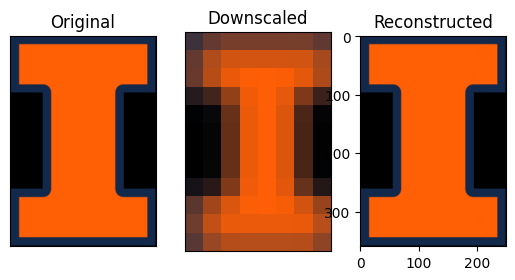

In [29]:

# Returns a "levels"-deep Laplacian pyramid of the given frame
def pyramidDownSample(frame, levels=5):
    G = frame.astype(np.float32)
    samples = [G]

    for i in range(levels):
        G = cv.pyrDown(G)
        samples.append(G)
    laplacianBase = samples[levels]
    laplacians = []
    for i in range(levels,0,-1):
        upsampled = cv.pyrUp(samples[i])
        upsampled = cv.resize(upsampled, (samples[i-1].shape[1], samples[i-1].shape[0]))
        L = cv.subtract(samples[i-1].astype(np.float32), upsampled.astype(np.float32))
        laplacians.append(L)
    
    return laplacianBase, laplacians

# Reconstructs the original image
def pyramidReconstruct(base, laplacians):
    G = base.astype(np.float32)
    for L in laplacians:
        G = cv.pyrUp(G)
        G = cv.resize(G, (L.shape[1], L.shape[0]))
        G = cv.add(G, L.astype(np.float32))
    return G

image = cv.imread("illinois.png")
lB, lS = pyramidDownSample(image)
reconstructed = pyramidReconstruct(lB, lS)
reconstructed = np.clip(reconstructed, 0, 255,).astype(np.uint8)
fig, axes = plt.subplots(1, 3)
axes[0].imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
axes[0].set_title('Original'), axes[0].set_xticks([]), axes[0].set_yticks([])
axes[2].imshow(cv.cvtColor(reconstructed, cv.COLOR_BGR2RGB))
axes[2].set_title('Reconstructed'), axes[1].set_xticks([]), axes[1].set_yticks([])
lB = np.clip(lB, 0, 255).astype(np.uint8)
axes[1].imshow(cv.cvtColor(lB, cv.COLOR_BGR2RGB))
axes[1].set_title('Downscaled'), axes[1].set_xticks([]), axes[1].set_yticks([])




In [15]:
video = cv.VideoCapture("guitar7.gif")
fps = video.get(cv.CAP_PROP_FPS)
low_hz, high_hz = 2.0, 8.0

print(fps)

14.916666666666666


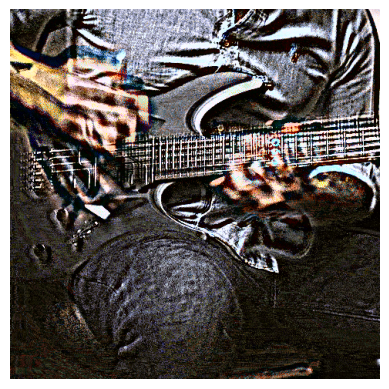

In [30]:
# Ideal Temporal Filter

levels = 3
alpha = 10
laplacian_stack = [[] for _ in range(levels)]
base_stack = []
low_hz, high_hz = 2.0, 7.0

video = cv.VideoCapture("guitar7.gif")
while(True):
    ret, levelFrame = video.read()
    if not ret:
        break
    baseFrame, laplacians = pyramidDownSample(cv.cvtColor(levelFrame, cv.COLOR_BGR2YUV), levels)
    base_stack.append(baseFrame)
    for i in range(levels):
        laplacian_stack[i].append(laplacians[i])

video.release()
cv.destroyAllWindows()

for i in range(levels):
    laplacian_stack[i] = np.array(laplacian_stack[i])
base_stack = np.array(base_stack)

N = len(base_stack)
freqs = np.fft.fftfreq(N, d=(1.0/fps))
mask = (np.abs(freqs) >= low_hz) & (np.abs(freqs) <= high_hz)

amplified_ls = []

for stack in laplacian_stack:
    decomp = np.fft.fft(stack, axis=0)
    decomp[~mask] = 0
    filtered = np.fft.ifft(decomp, axis=0).real
    amplified_stack = stack + (alpha * filtered)
    amplified_ls.append(amplified_stack)

final_frames = []
for e in range(len(base_stack)):
    currlap = [amplified_ls[i][e] for i in range(levels)]
    reconstructed = pyramidReconstruct(base_stack[e], currlap)
    final_rgb = cv.cvtColor(np.clip(reconstructed, 0, 255).astype(np.uint8), cv.COLOR_YUV2RGB)
    final_frames.append(final_rgb)

fig, ax = plt.subplots()
ax.axis('off')
im = ax.imshow(final_frames[0])
def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=final_frames, interval=50, blit=True)
ani.save("temporaloutput.mp4")


In [31]:
video = cv.VideoCapture("guitar7.gif")
fps = video.get(cv.CAP_PROP_FPS)
low_hz, high_hz = 2.0, 7.0
print(fps)

14.916666666666666


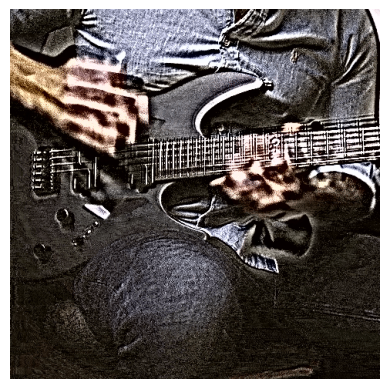

In [32]:
# Butterworth Filter
final_frames = []
levels = 3
alpha = 10
laplacian_stack = [[] for _ in range(levels)]
base_stack = []
b, a = signal.butter(N=1, Wn=[low_hz, high_hz], btype='bandpass', fs=fps)

ret, first_frame = video.read()
if ret:
    y_init, _, _ = cv.split(cv.cvtColor(first_frame, cv.COLOR_BGR2YUV))
    _, lap_init = pyramidDownSample(y_init, levels)
    prev_x = [[np.zeros_like(l, dtype=np.float32), np.zeros_like(l, dtype=np.float32)] for l in lap_init]
    prev_y = [[np.zeros_like(l, dtype=np.float32), np.zeros_like(l, dtype=np.float32)] for l in lap_init]
    video.set(cv.CAP_PROP_POS_FRAMES, 0)

while(True):
    ret, frame = video.read()
    if not ret: break

    yuv_frame = cv.cvtColor(frame, cv.COLOR_BGR2YUV)
    y, u, v = cv.split(yuv_frame)
    y_float = y.astype(np.float32) 
    base_img, laplacians = pyramidDownSample(y_float, levels)
    
    current_frame_laplacians = []
    
    for i in range(levels):
        x_curr = laplacians[i]
        
        y_curr = (b[0]*x_curr + b[1]*prev_x[i][0] + b[2]*prev_x[i][1] 
                  - a[1]*prev_y[i][0] - a[2]*prev_y[i][1]) / a[0]
        
        prev_x[i][1] = prev_x[i][0]
        prev_x[i][0] = x_curr
        prev_y[i][1] = prev_y[i][0]
        prev_y[i][0] = y_curr
        
        amplified_l = x_curr + (alpha * y_curr)
        current_frame_laplacians.append(amplified_l)

    reconstructed = pyramidReconstruct(base_img.astype(np.float32), current_frame_laplacians)
    recon_y = np.clip(reconstructed, 0, 255).astype(np.uint8)
    final_yuv = cv.merge([recon_y, u, v])
    final_bgr = cv.cvtColor(final_yuv, cv.COLOR_YUV2BGR)
    final_rgb = cv.cvtColor(final_bgr, cv.COLOR_BGR2RGB)
    final_frames.append(final_rgb)

video.release()
cv.destroyAllWindows()



fig, ax = plt.subplots()
ax.axis('off')
im = ax.imshow(final_frames[0])
def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=final_frames, interval=50, blit=True)
ani.save("butterworthoutput.mp4")


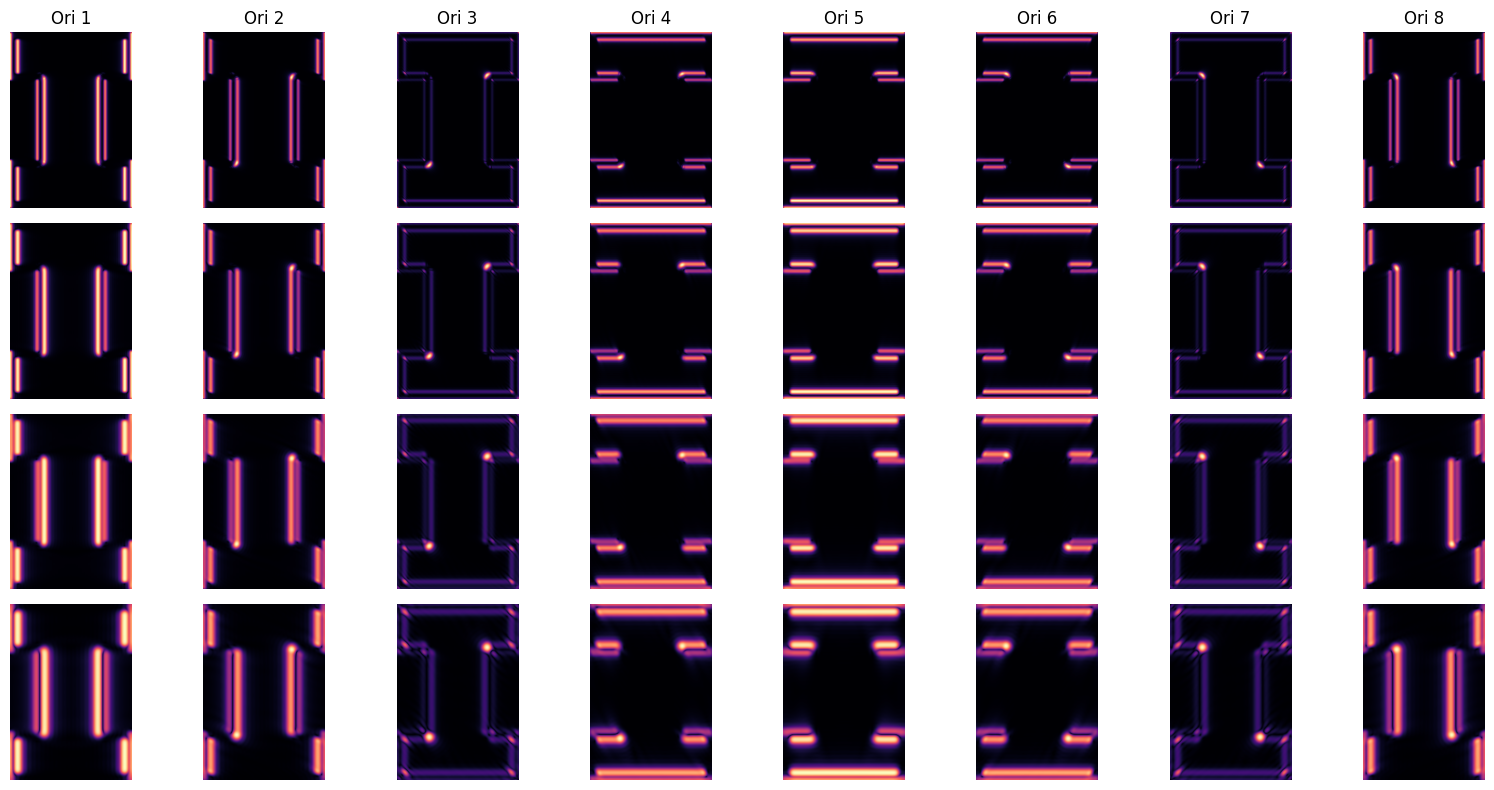

In [33]:
# Complex steerable pyramid decomposition (Wadhwa et al., 2013)

from math import factorial


def _wrap_to_pi(theta):
    return (theta + np.pi) % (2 * np.pi) - np.pi


def _frequency_grid(h, w):
    # Normalize coordinates to [-1, 1] so Nyquist = radius 1.0
    cy, cx = h // 2, w // 2
    fy = (np.arange(h) - cy) / max(cy, 1)
    fx = (np.arange(w) - cx) / max(cx, 1)
    wx, wy = np.meshgrid(fx, fy)

    radius = np.sqrt(wx ** 2 + wy ** 2)
    radius[radius == 0] = np.finfo(np.float32).eps
    angle = np.arctan2(wy, wx)
    return radius, angle, wx, wy


def _analytic_half_plane_mask(wx, wy):
    """
    One-sided frequency mask for complex steerable filters.
    Implements the paper's positive-frequency-only oriented bands.
    """
    mask = np.zeros_like(wx, dtype=np.float32)
    pos = (wx > 0) | ((wx == 0) & (wy > 0))
    boundary = (wx == 0) & (wy == 0)
    mask[pos] = 2.0
    mask[boundary] = 1.0
    return mask


def _raised_cosine_log_radial(radius, center_log2, filters_per_octave):
    """
    Radial window in log-frequency domain.
    filters_per_octave = 1 -> octave; 2 -> half-octave; 4 -> quarter-octave.
    Uses sqrt raised-cosine so adjacent hi/lo pairs satisfy hi^2 + lo^2 = 1.
    """
    t = filters_per_octave * (np.log2(radius) - center_log2)
    mask = np.zeros_like(radius, dtype=np.float32)
    # Transition region: t in (-1, 0) -> sqrt cosine
    lo_region = t <= -1
    tr_region = (t > -1) & (t < 0)
    mask[lo_region] = 1.0
    mask[tr_region] = np.cos(np.pi * (t[tr_region] + 1.0) / 2.0)
    return mask


def _radial_mask_pair(log_rad, r_val):
    """Sqrt raised-cosine hi/lo pair at boundary r_val. Satisfies hi^2+lo^2=1."""
    t = log_rad - np.log2(r_val)
    lo = np.zeros_like(log_rad, dtype=np.float32)
    hi = np.zeros_like(log_rad, dtype=np.float32)
    lo[t <= -1] = 1.0
    hi[t >= 0] = 1.0
    tr = (t > -1) & (t < 0)
    lo[tr] = np.cos(np.pi * (t[tr] + 1.0) / 2.0)
    hi[tr] = np.sin(np.pi * (t[tr] + 1.0) / 2.0)
    return hi, lo


def _angular_mask(angle, k, orientations):
    """Steerable angular window (Portilla/Simoncelli form used by Wadhwa et al.)."""
    order = orientations - 1
    theta_k = (np.pi * k) / orientations
    delta = _wrap_to_pi(angle - theta_k)

    mask = np.zeros_like(angle, dtype=np.float32)
    support = np.abs(delta) <= (np.pi / 2.0)
    mask[support] = np.cos(delta[support]) ** order

    norm = np.sqrt(2.0 * (2 ** (2*order)) * factorial(order)**2 / (orientations * factorial(2 * order)))
    return norm * mask


def complex_steerable_pyramid_decompose(frame, num_scales=3, orientations=8, filters_per_octave=2):
    """
    Decompose image into a complex steerable pyramid.

    This follows Wadhwa et al. (2013):
    - frequency-domain filtering,
    - complex oriented bands from positive frequencies only,
    - configurable octave/sub-octave radial tiling.

    Returns:
      {
        "highpass": real high-frequency residual,
        "bands": list[num_radial_bands] of list[orientations] complex bands,
        "lowpass": real low-frequency residual,
        "meta": {...}
      }
    """
    if frame.ndim == 3:
        gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    else:
        gray = frame
    gray = gray.astype(np.float32)

    h, w = gray.shape
    F = np.fft.fftshift(np.fft.fft2(gray))
    radius, angle, wx, wy = _frequency_grid(h, w)
    analytic_mask = _analytic_half_plane_mask(wx, wy)

    n_bands = num_scales * filters_per_octave

    # Boundary values from Nyquist (1.0) stepping down by half-octave
    log_rad = np.log2(radius)
    r_vals = [2.0 ** (-i / filters_per_octave) for i in range(n_bands + 2)]
    hi_res, lo_prev = _radial_mask_pair(log_rad, r_vals[0])
    highpass_mask = hi_res
    radial_masks = []
    for _k in range(1, len(r_vals)):
        hi_k, lo_k = _radial_mask_pair(log_rad, r_vals[_k])
        radial_masks.append(hi_k * lo_prev)
        lo_prev = lo_k
    lowpass_mask = lo_prev

    highpass = np.fft.ifft2(np.fft.ifftshift(F * highpass_mask)).real
    lowpass = np.fft.ifft2(np.fft.ifftshift(F * lowpass_mask)).real

    # Store filters and F for use in reconstruction
    band_filters = []
    bands = []
    for radial in radial_masks:
        per_orientation = []
        per_filter = []
        for k in range(orientations):
            ang = _angular_mask(angle, k, orientations)
            filt = radial * ang / 2.0
            per_filter.append(filt)
            per_orientation.append(np.fft.ifft2(np.fft.ifftshift(F * filt)))
        band_filters.append(per_filter)
        bands.append(per_orientation)

    return {
        "highpass": highpass,
        "bands": bands,
        "lowpass": lowpass,
        "band_filters": band_filters,
        "highpass_mask": highpass_mask,
        "lowpass_mask": lowpass_mask,
        "F": F,
        "meta": {
            "num_scales": num_scales,
            "orientations": orientations,
            "filters_per_octave": filters_per_octave,
            "num_radial_bands": n_bands,
        },
    }

def complex_steerable_pyramid_reconstruct(pyr):
    """
    Reconstructs the image from the complex steerable pyramid.
    Uses FFT-domain reconstruction: recon_F = hi^2*F + lo^2*F + sum(4*filter*fft2(band))
    The factor of 4 comes from: 2 (reconstruction) x 2 (compensates /2 in filter construction).
    """
    F            = pyr["F"]
    band_filters = pyr["band_filters"]
    hi_mask      = pyr["highpass_mask"]
    lo_mask      = pyr["lowpass_mask"]

    recon_F = F * hi_mask ** 2 + F * lo_mask ** 2
    for scale_bands, scale_filters in zip(pyr["bands"], band_filters):
        for band, filt in zip(scale_bands, scale_filters):
            band_F = np.fft.fftshift(np.fft.fft2(band))
            recon_F += 4.0 * filt * band_F

    return np.fft.ifft2(np.fft.ifftshift(recon_F)).real

# Sanity-check visualization (paper default is often 8 orientations, half-octave)
img = cv.imread("illinois.png")
pyr = complex_steerable_pyramid_decompose(img, num_scales=2, orientations=8, filters_per_octave=2)

rows = pyr["meta"]["num_radial_bands"]
cols = pyr["meta"]["orientations"]
fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
if rows == 1:
    axes = np.expand_dims(axes, axis=0)

for s in range(rows):
    for k in range(cols):
        coeff = pyr["bands"][s][k]
        axes[s, k].imshow(np.log1p(np.abs(coeff)), cmap="magma")
        axes[s, k].axis("off")
        if s == 0:
            axes[s, k].set_title(f"Ori {k + 1}")

plt.tight_layout()

In [20]:
video = cv.VideoCapture("guitar7.gif")
fps = video.get(cv.CAP_PROP_FPS)
print(fps)

14.916666666666666


In [21]:
def get_phasesamps(pyr):
    phases = []
    amplitudes = []
    for s in range(len(pyr["bands"])):
        scale_phases = []
        scale_amplitudes = []
        for o in range(len(pyr["bands"][s])):
            scale_phases.append(np.angle(pyr["bands"][s][o]))
            scale_amplitudes.append(np.abs(pyr["bands"][s][o]))
        phases.append(scale_phases)
        amplitudes.append(scale_amplitudes)
    return phases, amplitudes


Max filtered phase at t=19: 3.6614379376751516
Max alpha-magnified phase: 366.14379376751515


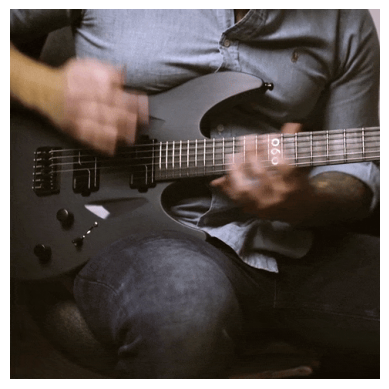

In [48]:
all_phases = []
all_amps = []
all_high = []
all_low = []
all_u = []
all_v = []
all_band_filters = []
all_hi_masks = []
all_lo_masks = []
all_F = []
frameNum = 0
alpha = 100
frame_count = 0
low_hz, high_hz = 2.0, 7.0

video = cv.VideoCapture("guitar7.gif")
while(True):
    ret, levelFrame = video.read()
    if not ret: break
    frame_count += 1
    yuv = cv.cvtColor(levelFrame, cv.COLOR_BGR2YUV)
    y,u,v = cv.split(yuv)
    pyr = complex_steerable_pyramid_decompose(y)
    phases, amps = get_phasesamps(pyr)
    if frame_count == 1:
        ref_amps = amps
        meta = pyr["meta"]

    all_phases.append(phases)
    all_amps.append(amps)
    all_high.append(pyr["highpass"])
    all_low.append(pyr["lowpass"])
    all_u.append(u)
    all_v.append(v)
    all_band_filters.append(pyr["band_filters"])
    all_hi_masks.append(pyr["highpass_mask"])
    all_lo_masks.append(pyr["lowpass_mask"])
    all_F.append(pyr["F"])

filtered_phases = []


phase_comp = np.array(all_phases)
for s in range(len(all_phases[0])):
    scale_filtered = []
    for o in range(len(all_phases[0][s])):
        band_stack = np.array([all_phases[t][s][o] for t in range(frame_count)])
        phase_diff = _wrap_to_pi(band_stack - band_stack[0])
        b, a = signal.butter(N=1, Wn=[low_hz, high_hz], btype='bandpass', fs=fps)
        band_filtered = signal.filtfilt(b, a, phase_diff, axis=0)
        scale_filtered.append(band_filtered)
    filtered_phases.append(scale_filtered)

final_frames = []
meta_data = pyr["meta"]

for t in range(frame_count):
    if t == frame_count // 2:
        max_val = np.max(np.abs(filtered_phases[0][0][t]))
        print(f"Max filtered phase at t={t}: {max_val}")
        print(f"Max alpha-magnified phase: {alpha * max_val}")

    current_bands = []
    for s in range(len(filtered_phases)):
        scale_bands = []
        for o in range(len(filtered_phases[s])):
            mag_phase = all_phases[t][s][o] + (alpha * filtered_phases[s][o][t])
            mag_phase = _wrap_to_pi(mag_phase)
            new_z = all_amps[t][s][o] * np.exp(1j * mag_phase)
            scale_bands.append(new_z)
        current_bands.append(scale_bands)

    mag_pyr = {
        "highpass": all_high[t],
        "bands": current_bands,
        "lowpass": all_low[t],
        "band_filters": all_band_filters[t],
        "highpass_mask": all_hi_masks[t],
        "lowpass_mask": all_lo_masks[t],
        "F": all_F[t],
        "meta": meta_data
    }
    
    recon_y = complex_steerable_pyramid_reconstruct(mag_pyr)
    recon_y = np.clip(recon_y, 0, 255).astype(np.uint8)
    u_curr, v_curr = all_u[t], all_v[t]
    if recon_y.shape != u_curr.shape:
        u_curr = cv.resize(u_curr, (recon_y.shape[1], recon_y.shape[0]))
        v_curr = cv.resize(v_curr, (recon_y.shape[1], recon_y.shape[0]))    
    final_yuv = cv.merge([recon_y, u_curr, v_curr])
    final_rgb = cv.cvtColor(final_yuv, cv.COLOR_YUV2RGB)
    final_frames.append(final_rgb)


video.release()

cv.destroyAllWindows()



fig, ax = plt.subplots()
ax.axis('off')
im = ax.imshow(final_frames[0], cmap='gray')
def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=final_frames, interval=50, blit=True)
ani.save("phase.mp4")

In [34]:
# Quantitative Evaluation Functions

def compute_snr(signal_data, noise_data):
    """
    Compute Signal-to-Noise Ratio (SNR) in dB.
    signal_data: array of signal values
    noise_data: array of noise values
    SNR = 10 * log10(mean(signal^2) / mean(noise^2))
    """
    signal_power = np.mean(signal_data ** 2)
    noise_power = np.mean(noise_data ** 2)
    if noise_power == 0:
        return float('inf')
    snr_db = 10 * np.log10(signal_power / noise_power)
    return snr_db

def compute_psnr(original, reconstructed):
    """
    Compute Peak Signal-to-Noise Ratio (PSNR) in dB.
    original: original image/frame
    reconstructed: reconstructed image/frame
    PSNR = 20 * log10(MAX / sqrt(MSE))
    where MAX is the maximum possible pixel value (255 for 8-bit images)
    """
    mse = np.mean((original.astype(np.float32) - reconstructed.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr_db = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr_db

def compute_reconstruction_error(original_frames, reconstructed_frames):
    """
    Compute average PSNR across a sequence of frames.
    Returns mean PSNR, min PSNR, max PSNR
    """
    psnrs = []
    for orig, recon in zip(original_frames, reconstructed_frames):
        if orig.ndim == 3:
            orig_gray = cv.cvtColor(orig, cv.COLOR_RGB2GRAY)
        else:
            orig_gray = orig
        if recon.ndim == 3:
            recon_gray = cv.cvtColor(recon, cv.COLOR_RGB2GRAY)
        else:
            recon_gray = recon
        if orig_gray.shape != recon_gray.shape:
            recon_gray = cv.resize(recon_gray, (orig_gray.shape[1], orig_gray.shape[0]))
        psnr = compute_psnr(orig_gray, recon_gray)
        psnrs.append(psnr)            
    
    return np.mean(psnrs), np.min(psnrs), np.max(psnrs)

In [35]:
# Wu et al. (Eulerian) Video Magnification Pipeline - Unified

def process_video_wu_et_al(video_path, levels=3, alpha=10, low_hz=2.0, high_hz=7.0, output_path=None, luma_only=True):
    """
    Process a video using Wu et al. (2012) Eulerian Video Magnification.
    Ideal temporal filtering approach.
    
    Args:
        video_path: Path to input video file
        levels: Number of Laplacian pyramid levels
        alpha: Amplification factor
        low_hz, high_hz: Temporal bandpass filter range (Hz)
        output_path: Where to save output video (optional)
    
    Returns:
        final_frames: List of processed frames (RGB)
        fps: Frames per second of input video
        frame_count: Number of frames processed
    """
    video = cv.VideoCapture(video_path)
    fps = video.get(cv.CAP_PROP_FPS)
    if fps == 0:
        fps = 24.0  # fallback
    
    laplacian_stack = [[] for _ in range(levels)]
    base_stack = []
    frame_count = 0
    original_frames = []
    
    print(f"Processing {video_path} with Wu et al. method (FPS: {fps})...")
    
    while True:
        ret, frame = video.read()
        if not ret:
            break
        frame_count += 1
        original_frames.append(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        
        baseFrame, laplacians = pyramidDownSample(cv.cvtColor(frame, cv.COLOR_BGR2YUV), levels)
        base_stack.append(baseFrame)
        for i in range(levels):
            laplacian_stack[i].append(laplacians[i])
    
    video.release()
    
    # Convert to arrays for FFT processing
    for i in range(levels):
        laplacian_stack[i] = np.array(laplacian_stack[i])
    base_stack = np.array(base_stack)
    
    # Frequency domain filtering
    N = len(base_stack)
    freqs = np.fft.fftfreq(N, d=(1.0/fps))
    mask = (np.abs(freqs) >= low_hz) & (np.abs(freqs) <= high_hz)
    
    amplified_ls = []
    for level_idx, stack in enumerate(laplacian_stack):
        if luma_only:
            y_stack  = stack[..., 0:1]
            uv_stack = stack[..., 1:]
            decomp = np.fft.fft(y_stack, axis=0)
            decomp[~mask] = 0
            filtered = np.fft.ifft(decomp, axis=0).real
            level_alpha = alpha / (2 ** level_idx)
            amplified_y = y_stack + (level_alpha * filtered)
            amplified_stack = np.concatenate([amplified_y, uv_stack], axis=-1)
        else:
            decomp = np.fft.fft(stack, axis=0)
            decomp[~mask] = 0
            filtered = np.fft.ifft(decomp, axis=0).real
            level_alpha = alpha / (2 ** level_idx)
            amplified_stack = stack + (level_alpha * filtered)
        amplified_ls.append(amplified_stack)
    
    # Reconstruct frames
    final_frames = []
    for e in range(len(base_stack)):
        currlap = [amplified_ls[i][e] for i in range(levels)]
        reconstructed = pyramidReconstruct(base_stack[e], currlap)
        final_rgb = cv.cvtColor(np.clip(reconstructed, 0, 255).astype(np.uint8), cv.COLOR_YUV2RGB)
        final_frames.append(final_rgb)
    
    # Save output video if requested
    if output_path:
        fig, ax = plt.subplots()
        ax.axis('off')
        im = ax.imshow(final_frames[0])
        def update(frame):
            im.set_data(frame)
            return [im]
        ani = animation.FuncAnimation(fig, update, frames=final_frames, interval=1000/fps, blit=True)
        ani.save(output_path)
        plt.close(fig)
        print(f"Output saved to {output_path}")
    
    print(f"Processed {frame_count} frames")
    return final_frames, fps, frame_count, original_frames

In [36]:
# Wadhwa et al. (Phase-Based) Video Magnification Pipeline - Unified

def process_video_wadhwa_et_al(video_path, num_scales=2, orientations=6, alpha=150,
                               low_hz=0.4, high_hz=3.0, output_path=None,
                               frame_skip=1, max_frames=None, resize_scale=1.0):
    """
    Process a video using Wadhwa et al. (2013) Phase-Based Video Motion Processing.

    Args:
        video_path: Path to input video file
        num_scales: Number of pyramid scales
        orientations: Number of orientations per scale
        alpha: Phase amplification factor
        low_hz, high_hz: Temporal bandpass filter range (Hz)
        output_path: Where to save output video (optional)
        frame_skip: Process every Nth frame (1 = all frames)
        max_frames: Hard cap on number of frames to process
        resize_scale: Downsample frames by this factor before processing

    Returns:
        final_frames: List of processed frames (RGB)
        fps: Frames per second of input video
        frame_count: Number of frames processed
        original_frames: List of original frames (RGB)
    """
    video = cv.VideoCapture(video_path)
    fps = video.get(cv.CAP_PROP_FPS)
    if fps == 0:
        fps = 24.0  # fallback
    eff_fps = fps / frame_skip

    all_phases = []
    all_amps = []
    all_high = []
    all_low = []
    all_band_filters = []
    all_hi_masks = []
    all_lo_masks = []
    all_F = []
    all_u = []
    all_v = []
    original_frames = []
    frame_count = 0

    print(f"Processing {video_path} with Wadhwa et al. method (FPS: {fps})...")
    print("Decomposing frames into complex steerable pyramids...")

    # Frame decomposition
    frame_index = 0
    while True:
        ret, frame = video.read()
        if not ret:
            break
        frame_index += 1

        # Skip frames if requested
        if frame_index % frame_skip != 0:
            continue

        # Limit total frames if requested
        if max_frames and frame_count >= max_frames:
            break

        frame_count += 1

        # Resize frame to reduce memory
        if resize_scale < 1.0:
            h, w = frame.shape[:2]
            frame = cv.resize(frame, (int(w * resize_scale), int(h * resize_scale)))

        original_frames.append(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        
        yuv = cv.cvtColor(frame, cv.COLOR_BGR2YUV)
        y, u, v = cv.split(yuv)
        pyr = complex_steerable_pyramid_decompose(y, num_scales=num_scales, orientations=orientations)
        phases, amps = get_phasesamps(pyr)
        
        all_phases.append(phases)
        all_amps.append(amps)
        all_high.append(pyr["highpass"])
        all_low.append(pyr["lowpass"])
        all_band_filters.append(pyr["band_filters"])
        all_hi_masks.append(pyr["highpass_mask"])
        all_lo_masks.append(pyr["lowpass_mask"])
        all_F.append(pyr["F"])
        all_u.append(u)
        all_v.append(v)

        # Progress indicator
        if frame_count % 10 == 0:
            print(f"  Processed {frame_count} frames ({frame_index} total read)...")

    video.release()
    print(f"Decomposition complete: {frame_count} frames processed.")

    # Temporal phase filtering
    print("Applying temporal bandpass filter to phases...")
    b, a = signal.butter(N=2, Wn=[low_hz, high_hz], btype='bandpass', fs=eff_fps)

    filtered_phases = []
    for s in range(len(all_phases[0])):
        scale_filtered = []
        for o in range(len(all_phases[0][s])):
            band_stack = np.array([all_phases[t][s][o] for t in range(frame_count)])
            phase_diff = _wrap_to_pi(band_stack - band_stack[0])
            band_filtered = signal.filtfilt(b, a, phase_diff, axis=0)
            scale_filtered.append(band_filtered)
        filtered_phases.append(scale_filtered)

    # Reconstruct frames with amplified phases
    print("Reconstructing amplified frames...")
    final_frames = []
    meta_data = pyr["meta"]

    for t in range(frame_count):
        current_bands = []
        for s in range(len(filtered_phases)):
            scale_bands = []
            for o in range(len(filtered_phases[s])):
                mag_phase = all_phases[t][s][o] + (alpha * filtered_phases[s][o][t])
                mag_phase = _wrap_to_pi(mag_phase)
                new_z = all_amps[t][s][o] * np.exp(1j * mag_phase)
                scale_bands.append(new_z)
            current_bands.append(scale_bands)
        
        mag_pyr = {
            "highpass": all_high[t],
            "bands": current_bands,
            "lowpass": all_low[t],
            "band_filters": all_band_filters[t],
            "highpass_mask": all_hi_masks[t],
            "lowpass_mask": all_lo_masks[t],
            "F": all_F[t],
            "meta": meta_data
        }
        
        recon_y = complex_steerable_pyramid_reconstruct(mag_pyr)
        recon_y = np.clip(recon_y, 0, 255).astype(np.uint8)
        u_curr, v_curr = all_u[t], all_v[t]
        if recon_y.shape != u_curr.shape:
            u_curr = cv.resize(u_curr, (recon_y.shape[1], recon_y.shape[0]))
            v_curr = cv.resize(v_curr, (recon_y.shape[1], recon_y.shape[0]))
        
        final_yuv = cv.merge([recon_y, u_curr, v_curr])
        final_rgb = cv.cvtColor(final_yuv, cv.COLOR_YUV2RGB)
        final_frames.append(final_rgb)
    
    # Save output video if requested
    if output_path:
        fig, ax = plt.subplots()
        ax.axis('off')
        im = ax.imshow(final_frames[0])
        def update(frame):
            im.set_data(frame)
            return [im]
        ani = animation.FuncAnimation(fig, update, frames=final_frames, interval=1000/eff_fps, blit=True)
        ani.save(output_path)
        plt.close(fig)
        print(f"Output saved to {output_path}")
    
    print(f"Processed {frame_count} frames")
    return final_frames, fps, frame_count, original_frames

In [37]:
# Validation on Standard Test Videos (MIT EVM Dataset)

def compare_methods_on_video(video_path, output_dir="results",
                             wu_alpha=None, wu_low=None, wu_high=None,
                             wad_alpha=None, wad_low=None, wad_high=None,
                             wad_frame_skip=1, wad_max_frames=200, wad_resize=0.5):
    """
    Compare Wu et al. and Wadhwa et al. methods on a single video.
    Computes PSNR, visual quality metrics, and saves comparative outputs.
    
    Args:
        video_path: Path to input video file
        output_dir: Directory to save results
    
    Returns:
        results: Dictionary with comparison metrics
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    
    print(f"\n{'='*60}")
    print(f"Comparing methods on: {video_name}")
    print(f"{'='*60}")
    
    # Process with Wu et al.
    # Baby/motion: bandpass 0.4-3 Hz (breathing ~0.5 Hz), alpha=150
    # Face/color:  bandpass 0.4-4 Hz captures heartbeat (~0.8-1.3 Hz), alpha=50
    is_face = "face" in video_name.lower()
    _wu_low   = wu_low   if wu_low   is not None else (0.4 if is_face else 0.4)
    _wu_high  = wu_high  if wu_high  is not None else (4.0 if is_face else 3.0)
    _wu_alpha = wu_alpha if wu_alpha is not None else (50  if is_face else 150)
    _wad_low  = wad_low  if wad_low  is not None else (0.4 if is_face else 0.4)
    _wad_high = wad_high if wad_high is not None else (4.0 if is_face else 1.0)
    _wad_alpha= wad_alpha if wad_alpha is not None else (50 if is_face else 300)

    wu_frames, fps, frame_count, orig_frames = process_video_wu_et_al(
        video_path,
        levels=3,
        alpha=_wu_alpha,
        low_hz=_wu_low,
        high_hz=_wu_high,
        output_path=os.path.join(output_dir, f"{video_name}_wu.mp4"),
        luma_only=not is_face
    )
    
    # Compute Wu et al. PSNR
    wu_mean_psnr, wu_min_psnr, wu_max_psnr = compute_reconstruction_error(orig_frames, wu_frames)

    wadhwa_frames, _, _, _ = process_video_wadhwa_et_al(
        video_path,
        num_scales=2,
        orientations=6,
        alpha=_wad_alpha,
        low_hz=_wad_low,
        high_hz=_wad_high,
        output_path=os.path.join(output_dir, f"{video_name}_wadhwa.mp4"),
        frame_skip=wad_frame_skip,
        max_frames=wad_max_frames,
        resize_scale=wad_resize
    )
    
    # Compute Wadhwa et al. PSNR
    wadhwa_mean_psnr, wadhwa_min_psnr, wadhwa_max_psnr = compute_reconstruction_error(orig_frames, wadhwa_frames)
    
    # Compute frame difference statistics
    wu_diffs = []
    wadhwa_diffs = []
    for orig, wu, wadhwa in zip(orig_frames, wu_frames, wadhwa_frames):
        orig_gray = cv.cvtColor(orig, cv.COLOR_RGB2GRAY) if orig.ndim == 3 else orig
        wu_gray = cv.cvtColor(wu, cv.COLOR_RGB2GRAY) if wu.ndim == 3 else wu
        wadhwa_gray = cv.cvtColor(wadhwa, cv.COLOR_RGB2GRAY) if wadhwa.ndim == 3 else wadhwa
        if orig_gray.shape != wadhwa_gray.shape:
            wadhwa_gray = cv.resize(wadhwa_gray, (orig_gray.shape[1], orig_gray.shape[0]))
        wu_diffs.append(np.mean(np.abs(orig_gray.astype(np.float32) - wu_gray.astype(np.float32))))
        wadhwa_diffs.append(np.mean(np.abs(orig_gray.astype(np.float32) - wadhwa_gray.astype(np.float32))))

    results = {
        'video_name': video_name,
        'fps': fps,
        'frame_count': frame_count,
        'wu_mean_psnr': wu_mean_psnr,
        'wu_min_psnr': wu_min_psnr,
        'wu_max_psnr': wu_max_psnr,
        'wadhwa_mean_psnr': wadhwa_mean_psnr,
        'wadhwa_min_psnr': wadhwa_min_psnr,
        'wadhwa_max_psnr': wadhwa_max_psnr,
        'wu_mean_diff': np.mean(wu_diffs),
        'wadhwa_mean_diff': np.mean(wadhwa_diffs),
    }
    
    print(f"\n--- Wu et al. (Eulerian) Results ---")
    print(f"Mean PSNR: {wu_mean_psnr:.2f} dB")
    print(f"Min PSNR:  {wu_min_psnr:.2f} dB")
    print(f"Max PSNR:  {wu_max_psnr:.2f} dB")
    print(f"Mean Absolute Difference: {results['wu_mean_diff']:.2f}")
    
    print(f"\n--- Wadhwa et al. (Phase-Based) Results ---")
    print(f"Mean PSNR: {wadhwa_mean_psnr:.2f} dB")
    print(f"Min PSNR:  {wadhwa_min_psnr:.2f} dB")
    print(f"Max PSNR:  {wadhwa_max_psnr:.2f} dB")
    print(f"Mean Absolute Difference: {results['wadhwa_mean_diff']:.2f}")
    
    print(f"\n--- Comparative Analysis ---")
    psnr_diff = wu_mean_psnr - wadhwa_mean_psnr
    if psnr_diff > 0:
        print(f"Wu et al. has {psnr_diff:.2f} dB higher mean PSNR")
    else:
        print(f"Wadhwa et al. has {abs(psnr_diff):.2f} dB higher mean PSNR")
    
    return results, wu_frames, wadhwa_frames

all_results = []


In [41]:
# --- Baby breathing amplification ---
video_file = "source_videos/baby.wmv"
description = "Baby breathing amplification"

if os.path.exists(video_file):
    print(f"\nTesting: {description}")
    results, wu_out, wadhwa_out = compare_methods_on_video(
        video_file,
        wu_alpha=150,  wu_low=0.4, wu_high=3.0,
        wad_alpha=150, wad_low=0.4, wad_high=3.0,
        wad_frame_skip=1, wad_max_frames=200, wad_resize=0.5
    )
    all_results.append(results)
else:
    print(f"Skipping {video_file} - file not found")



Testing: Baby breathing amplification

Comparing methods on: baby
Processing source_videos/baby.wmv with Wu et al. method (FPS: 30.0)...
Output saved to results\baby_wu.mp4
Processed 301 frames
Processing source_videos/baby.wmv with Wadhwa et al. method (FPS: 30.0)...
Decomposing frames into complex steerable pyramids...
  Processed 10 frames (10 total read)...
  Processed 20 frames (20 total read)...
  Processed 30 frames (30 total read)...
  Processed 40 frames (40 total read)...
  Processed 50 frames (50 total read)...
  Processed 60 frames (60 total read)...
  Processed 70 frames (70 total read)...
  Processed 80 frames (80 total read)...
  Processed 90 frames (90 total read)...
  Processed 100 frames (100 total read)...
  Processed 110 frames (110 total read)...
  Processed 120 frames (120 total read)...
  Processed 130 frames (130 total read)...
  Processed 140 frames (140 total read)...
  Processed 150 frames (150 total read)...
  Processed 160 frames (160 total read)...
  Proc

In [44]:
# --- Face color amplification ---
video_file = "source_videos/face.wmv"
description = "Face color amplification"

if os.path.exists(video_file):
    print(f"\nTesting: {description}")
    results, wu_out, wadhwa_out = compare_methods_on_video(
        video_file,
        wu_alpha=50,  wu_low=0.4, wu_high=4.0,
        wad_alpha=50, wad_low=0.4, wad_high=4.0,
        wad_frame_skip=1, wad_max_frames=200, wad_resize=0.5
    )
    all_results.append(results)
else:
    print(f"Skipping {video_file} - file not found")


Testing: Face color amplification

Comparing methods on: face
Processing source_videos/face.wmv with Wu et al. method (FPS: 30.0)...
Output saved to results\face_wu.mp4
Processed 301 frames
Processing source_videos/face.wmv with Wadhwa et al. method (FPS: 30.0)...
Decomposing frames into complex steerable pyramids...
  Processed 10 frames (10 total read)...
  Processed 20 frames (20 total read)...
  Processed 30 frames (30 total read)...
  Processed 40 frames (40 total read)...
  Processed 50 frames (50 total read)...
  Processed 60 frames (60 total read)...
  Processed 70 frames (70 total read)...
  Processed 80 frames (80 total read)...
  Processed 90 frames (90 total read)...
  Processed 100 frames (100 total read)...
  Processed 110 frames (110 total read)...
  Processed 120 frames (120 total read)...
  Processed 130 frames (130 total read)...
  Processed 140 frames (140 total read)...
  Processed 150 frames (150 total read)...
  Processed 160 frames (160 total read)...
  Processe

In [43]:
# --- Crane motion amplification ---
video_file = "source_videos/crane.avi"
description = "Crane motion amplification"

if os.path.exists(video_file):
    print(f"\nTesting: {description}")
    results, wu_out, wadhwa_out = compare_methods_on_video(
        video_file,
        wu_alpha=150,  wu_low=0.2, wu_high=0.4,
        wad_alpha=150, wad_low=0.2, wad_high=0.4,
        wad_frame_skip=1, wad_max_frames=200, wad_resize=0.5
    )
    all_results.append(results)
else:
    print(f"Skipping {video_file} - file not found")



Testing: Crane motion amplification

Comparing methods on: crane
Processing source_videos/crane.avi with Wu et al. method (FPS: 24.0)...
Output saved to results\crane_wu.mp4
Processed 215 frames
Processing source_videos/crane.avi with Wadhwa et al. method (FPS: 24.0)...
Decomposing frames into complex steerable pyramids...
  Processed 10 frames (10 total read)...
  Processed 20 frames (20 total read)...
  Processed 30 frames (30 total read)...
  Processed 40 frames (40 total read)...
  Processed 50 frames (50 total read)...
  Processed 60 frames (60 total read)...
  Processed 70 frames (70 total read)...
  Processed 80 frames (80 total read)...
  Processed 90 frames (90 total read)...
  Processed 100 frames (100 total read)...
  Processed 110 frames (110 total read)...
  Processed 120 frames (120 total read)...
  Processed 130 frames (130 total read)...
  Processed 140 frames (140 total read)...
  Processed 150 frames (150 total read)...
  Processed 160 frames (160 total read)...
  Pr

In [45]:
# Save all_results to disk
import json, os

os.makedirs("results", exist_ok=True)
def convert(obj):
    if isinstance(obj, dict):
        return {k: convert(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [convert(v) for v in obj]
    if hasattr(obj, 'item'):
        return obj.item()
    return obj

with open("results/all_results.json", "w") as f:
    json.dump(convert(all_results), f, indent=2)
print("Results saved to results/all_results.json")

Results saved to results/all_results.json


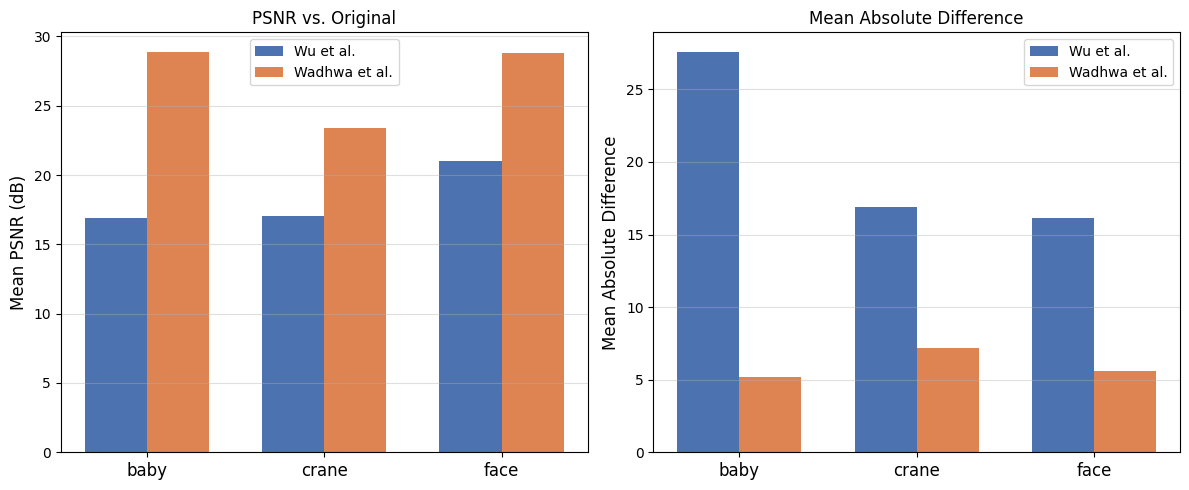

Figure saved to results/comparison_figure.png


In [47]:
# Load saved results and generate comparison figures
import json
import matplotlib.pyplot as plt
import numpy as np

with open("results/all_results.json") as f:
    all_results = json.load(f)

videos     = [r["video_name"]       for r in all_results]
wu_psnr    = [r["wu_mean_psnr"]     for r in all_results]
wad_psnr   = [r["wadhwa_mean_psnr"] for r in all_results]
wu_mad     = [r["wu_mean_diff"]     for r in all_results]
wad_mad    = [r["wadhwa_mean_diff"] for r in all_results]

x = np.arange(len(videos))
w = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# PSNR
ax1.bar(x - w/2, wu_psnr,  w, label="Wu et al.",     color="#4C72B0")
ax1.bar(x + w/2, wad_psnr, w, label="Wadhwa et al.", color="#DD8452")
ax1.set_xticks(x); ax1.set_xticklabels(videos, fontsize=12)
ax1.set_ylabel("Mean PSNR (dB)", fontsize=12)
ax1.set_title("PSNR vs. Original", fontsize=12)
ax1.legend(); ax1.grid(axis="y", alpha=0.4)

# MAD
ax2.bar(x - w/2, wu_mad,  w, label="Wu et al.",     color="#4C72B0")
ax2.bar(x + w/2, wad_mad, w, label="Wadhwa et al.", color="#DD8452")
ax2.set_xticks(x); ax2.set_xticklabels(videos, fontsize=12)
ax2.set_ylabel("Mean Absolute Difference", fontsize=12)
ax2.set_title("Mean Absolute Difference", fontsize=12)
ax2.legend(); ax2.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("results/comparison_figure.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to results/comparison_figure.png")